## Analisis Pola Penyewaan Sepeda Berdasarkan Waktu dan Kondisi Cuaca

### Anggota Kelompok 1 : 
1) **Ester** Yelisabeta - 5027261005
2) Muhammad **Naufal** Azmi - 5027261059
3) Muhammad **Ikhsanul** Amal - 5027161117

### Topik : Smart City - Bike Sharing

### Latar Belakang 
Penyewaan sepeda bersama atau yang biasa disebut bike sharing merupakan salah satu penerapan konsep smart city yang dapat membantu masyarakat dalam memenuhi kebutuhan transportasi sehari-hari. Dengan adanya layanan bike sharing, kami tertarik untuk memahami data mengenai penyewaan sepeda bersama dan mengetahui faktor-faktor yang berkaitan dengan jumlah penyewaan. Dataset yang kami analisis berjudul “Permintaan Penyewaan Sepeda per Jam & Cuaca”. Kami tertarik menganalisis dataset ini karena menunjukkan bagaimana jumlah penyewaan sepeda berubah berdasarkan waktu dan kondisi cuaca. Dari data tersebut, kami dapat melihat kapan sepeda paling banyak atau paling sedikit disewa serta bagaimana kondisi cuaca pada saat penyewaan terjadi.

### Pertanyaan Analisis 
1) Pada jam berapa jumlah penyewaan sepeda paling tinggi dan rendah?
2) Bagaimana perbedaan jumlah penyewaan sepeda berdasarkan kondisi cuaca?
3) Bagaimana rata-rata jumlah penyewaan sepeda berdasarkan waktu/ jam?

### Memuat Data

In [1]:
import pandas as pd

df = pd.read_csv("data/bike_sharing_hourly.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.head()

(17379, 19)


,record_id,datetime,date,year,month,hour,weekday,season,is_holiday,is_working_day,is_weekend,weather_condition,temperature_normalized,feels_like_temperature_normalized,humidity_percent,wind_speed_normalized,casual_rentals,registered_rentals,total_rentals
0,1,2011-01-01 00:00:00,2011-01-01,2011,1,0,Saturday,Winter,0,0,1,Clear or partly cloudy,0.24,0.2879,81.0,0.0,3,13,16
1,2,2011-01-01 01:00:00,2011-01-01,2011,1,1,Saturday,Winter,0,0,1,Clear or partly cloudy,0.22,0.2727,80.0,0.0,8,32,40
2,3,2011-01-01 02:00:00,2011-01-01,2011,1,2,Saturday,Winter,0,0,1,Clear or partly cloudy,0.22,0.2727,80.0,0.0,5,27,32
3,4,2011-01-01 03:00:00,2011-01-01,2011,1,3,Saturday,Winter,0,0,1,Clear or partly cloudy,0.24,0.2879,75.0,0.0,3,10,13
4,5,2011-01-01 04:00:00,2011-01-01,2011,1,4,Saturday,Winter,0,0,1,Clear or partly cloudy,0.24,0.2879,75.0,0.0,0,1,1


Setiap baris pada dataset menunjukkan data penyewaan sepeda dalam satu jam tertentu, seperti **waktu, kondisi cuaca dan jumlah sepeda yang disewa.**

### Deskripsi Data dan Kamus Data

Sumber Data: Diambil dari dataset publik Kaggle (Bike Sharing Demand: Hourly Rentals & Weather) https://www.kaggle.com/datasets/muhammadishahrukh/bike-sharing-demand-hourly-rentals-and-weather dengan lisensi CC BY-NC-SA 4.0 (Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International)  

Pengumpulan data: Dikumpulkan oleh Muhammad Ibrahim Shahrukh menggunakan data berdasarkan data asli penyewaan sepeda UCI (Capital Bikeshare system) https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset dan https://doi.org/10.24432/C5W894. Data mencakup dari tahun 2011 bulan Januari tanggal 1 hingga 2012 bulan Desember tanggal 31.  

Jumlah Baris dan Kolom: 17.379 baris dan 19 kolom  

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh | 
| :--- | :--- | :--- | :--- | :--- | :--- | 
| `record_id` | Indeks/ID unik setiap baris data | Kuantitatif diskrit | Nominal | – | 1 |
| `datetime` | Tanggal dan jam pencatatan | Kualitatif | Ordinal | YYYY-MM-DD HH:MM:SS | 2011-01-01 00:00:00 |
| `date` | Tanggal pencatatan | Kualitatif | Ordinal | YYYY-MM-DD | 2011-01-01 |
| `year` | Tahun pencatatan | Kuantitatif diskrit | Interval | Tahun | 2011 |
| `month` | Bulan pencatatan (1 s.d. 12) | Kualitatif | Ordinal | Bulan | 1 |
| `hour` | Jam pencatatan (0 s.d. 23) | Kualitatif | Ordinal | Jam | 0 |
| `weekday` | Nama hari dalam seminggu | Kualitatif | Nominal | – | Saturday |
| `season` | Musim saat pengukuran | Kualitatif | Nominal | – | Winter |
| `is_holiday` | Penanda apakah hari libur nasional (1=Ya, 0=Tidak) | Kualitatif | Nominal | – | 0 |
| `is_working_day` | Penanda apakah hari kerja (1=Ya, 0=Tidak) | Kualitatif | Nominal | – | 0 |
| `is_weekend` | Penanda apakah akhir pekan (1=Ya, 0=Tidak) | Kualitatif | Nominal | – | 1 |
| `weather_condition` | Kondisi cuaca saat pengukuran | Kualitatif | Ordinal | – | Clear or partly cloudy |
| `temperature_normalized` | Suhu lingkungan ternormalisasi | Kuantitatif kontinu | Rasio | Skala (0 s.d. 1) | 0.24 |
| `feels_like_temperature_normalized` | Suhu yang dirasakan (*feels like*) ternormalisasi | Kuantitatif kontinu | Rasio | Skala (0 s.d. 1) | 0.2879 |
| `humidity_percent` | Persentase kelembapan udara | Kuantitatif kontinu | Rasio | % | 81.0 |
| `wind_speed_normalized` | Kecepatan angin ternormalisasi | Kuantitatif kontinu | Rasio | Skala (0 s.d. 1) | 0.0 |
| `casual_rentals` | Jumlah penyewaan oleh pengguna non-berlangganan | Kuantitatif diskrit | Rasio | Unit sepeda | 3 |
| `registered_rentals` | Jumlah penyewaan oleh pengguna terdaftar/berlangganan | Kuantitatif diskrit | Rasio | Unit sepeda | 13 |
| `total_rentals` | Jumlah total penyewaan sepeda per jam | Kuantitatif diskrit | Rasio | Unit sepeda | 16 |

### Pemeriksaan Kualitas Data

In [2]:
import pandas as pd
df = pd.read_csv("data/bike_sharing_hourly.csv")
df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   record_id                          17379 non-null  int64  
 1   datetime                           17379 non-null  str    
 2   date                               17379 non-null  str    
 3   year                               17379 non-null  int64  
 4   month                              17379 non-null  int64  
 5   hour                               17379 non-null  int64  
 6   weekday                            17379 non-null  str    
 7   season                             17379 non-null  str    
 8   is_holiday                         17379 non-null  int64  
 9   is_working_day                     17379 non-null  int64  
 10  is_weekend                         17379 non-null  int64  
 11  weather_condition                  17379 non-null  str    
 12  t

np.int64(0)

Dataset bike_sharing_hourly.csv ini sudah sangat bersih dan siap untuk tahap selanjutnya tanpa memerlukan pembresihan missing value maupun duplikasi.

### Statistik Deskriptif Variabel Numberik

Di tahapan ini, dilakukan analisis deskripstif pada 3 variabl numerik, yaitu `total_rentals`, `humidity_percent`, dan `temperature_normalized`. Mengapa pilih 3 variabel tersebut? Karena berkaitan dengan jumlah penyewaan sepeda dan kondisi cuaca sesuai dengan tujuan analisis.

In [3]:
kolom = df[[
    'total_rentals',
    'temperature_normalized',
    'humidity_percent',
]]

kolom.head()

,total_rentals,temperature_normalized,humidity_percent
0,16,0.24,81.0
1,40,0.22,80.0
2,32,0.22,80.0
3,13,0.24,75.0
4,1,0.24,75.0


#### A. Ukuran Pemusatan 
Digunakan untuk melihat nilai yang mewakili data, pada bagian ini digunakan *mean, median* dan *modus*.

In [4]:
print("Mean: ")
print(kolom.mean())

print("\nMedian: ")
print(kolom.median())

print("\nModus: ")
print(kolom.mode().iloc[0])

Mean: 
total_rentals             189.463088
temperature_normalized      0.496987
humidity_percent           62.722884
dtype: float64

Median: 
total_rentals             142.0
temperature_normalized      0.5
humidity_percent           63.0
dtype: float64

Modus: 
total_rentals              5.00
temperature_normalized     0.62
humidity_percent          88.00
Name: 0, dtype: float64


#### B. Ukuran Penyebaran
Digunakan untuk melihat seberapa jauh nilai-nilai dalam data tersebar. Ukuran yang digunakan adalah *nilai minimum, maksimum, jangkauan, varians* dan *simpangan baku.*

In [5]:
print("Minimum:")
print(kolom.min())

print("\nMaksimum:")
print(kolom.max())

print("\nJangkauan:")
print(kolom.max() - kolom.min())

print("\nVarians:")
print(kolom.var())

print("\nSimpangan Baku:")
print(kolom.std())

Minimum:
total_rentals             1.00
temperature_normalized    0.02
humidity_percent          0.00
dtype: float64

Maksimum:
total_rentals             977.0
temperature_normalized      1.0
humidity_percent          100.0
dtype: float64

Jangkauan:
total_rentals             976.00
temperature_normalized      0.98
humidity_percent          100.00
dtype: float64

Varians:
total_rentals             32901.461104
temperature_normalized        0.037078
humidity_percent            372.219209
dtype: float64

Simpangan Baku:
total_rentals             181.387599
temperature_normalized      0.192556
humidity_percent           19.292983
dtype: float64


#### C. Ukuran Letak
Digunakan untuk melihat posisi data dalam distribusi. Ukuran yang digunakan adalah *Q1, Q3* dan *IQR.*

In [6]:
q1 = kolom.quantile(0.25)
q3 = kolom.quantile(0.75)
iqr = q3 - q1

print("Q1:")
print(q1)

print("\nQ3:")
print(q3)

print("\nIQR:")
print(iqr)

Q1:
total_rentals             40.00
temperature_normalized     0.34
humidity_percent          48.00
Name: 0.25, dtype: float64

Q3:
total_rentals             281.00
temperature_normalized      0.66
humidity_percent           78.00
Name: 0.75, dtype: float64

IQR:
total_rentals             241.00
temperature_normalized      0.32
humidity_percent           30.00
dtype: float64


In [7]:
tabelRangkum = pd.DataFrame({
    'Mean': kolom.mean(),
    'Median' : kolom.median(),
    'Modus' : kolom.mode().iloc[0],
    'Minimum' : kolom.min(),
    'Maksimal' : kolom.max(),
    'Jangkauan' : kolom.max() - kolom.min(),
    'Varians' : kolom.var(),
    'Simpangan Baku' : kolom.std(),
    'Q1' : kolom.quantile(0.25),
    'Q2' : kolom.quantile(0.75),
    'IQR' : kolom.quantile(0.75) - kolom.quantile(0.25),
})

tabelRangkum

,Mean,Median,Modus,Minimum,Maksimal,Jangkauan,Varians,Simpangan Baku,Q1,Q2,IQR
total_rentals,189.463088,142.0,5.00,1.00,977.0,976.00,32901.461104,181.387599,40.00,281.00,241.00
temperature_normalized,0.496987,0.5,0.62,0.02,1.0,0.98,0.037078,0.192556,0.34,0.66,0.32
humidity_percent,62.722884,63.0,88.00,0.00,100.0,100.00,372.219209,19.292983,48.00,78.00,30.00


#### Interpretasi 

Berdasarkan hasil analisis, `total_rentals` memiliki rata-rata **189,46 sepeda per jam** dan median **142 sepeda per jam**. Perbedaan yang cukup besar antara rata-rata dan median menunjukkan bahwa distribusi data **cenderung miring ke kanan**, karena terdapat beberapa nilai penyewaan yang sangat tinggi. Sementara itu, `temperature_normalized` memiliki rata-rata dan median yang sama, yaitu sekitar **0,50**, sehingga sebarannya **cenderung lebih seimbang**. Pada `humidity_percent`, rata-rata sebesar **62,72%** dan median **63%** juga menunjukkan bahwa **sebaran datanya relatif seimbang.**

#### Perhitungan Variabel Manual

In [8]:
data_10 = df['total_rentals'].head(10)
data_10

0    16
1    40
2    32
3    13
4     1
5     1
6     2
7     3
8     8
9    14
Name: total_rentals, dtype: int64

In [9]:
n = len(data_10)
mean_10 = data_10.mean()
varManual = ((data_10 - mean_10) ** 2). sum() / (n-1)
varPandas = data_10.var()

print("Jumlah data:", n)
print("Rata-rata:", mean_10)
print("Variabel manual:", varManual)
print("Varians Pandas:", varPandas)

Jumlah data: 10
Rata-rata: 13.0
Variabel manual: 181.55555555555554
Varians Pandas: 181.55555555555554


Varian manual dan varian pandas setelah dihitung, menghasilkan nilai yang sama yaitu 181.56. Hal ini berarti perhitungan manual sudah sesuai dengan perhitungan pandas.

In [4]:
tabel_frekuensi = df["weather_main"].value_counts()                                  # value_counts() mengurutkan hasil dari terbanyak-tersedikit
tabel_persentase = df["weather_main"].value_counts(normalize=True) * 100             # Menghitung persen, mengubah menjadi desimal lalu dikalikan 100

ringkasan_kategorik = pd.DataFrame({
    "Frekuensi (Jam)": tabel_frekuensi,
    "Persentase (%)": tabel_persentase
})

print("Ringkasan Variabel Kategorik (weather_main):")
print(ringkasan_kategorik.round(2))                                                  # .round(2) membatasi 2 angka di belakang koma

modus_cuaca = tabel_frekuensi.idxmax()                                               # .idxmax() mengambil nama kategori frekuensi terbanyak
print(f"\nKategori cuaca yang paling sering muncul (Modus) adalah: {modus_cuaca}")    

Ringkasan Variabel Kategorik (weather_main):
              Frekuensi (Jam)  Persentase (%)
weather_main                                 
Clouds                  15164           31.46
Clear                   13391           27.78
Mist                     5950           12.34
Rain                     5672           11.77
Snow                     2876            5.97
Drizzle                  1821            3.78
Haze                     1360            2.82
Thunderstorm             1034            2.15
Fog                       912            1.89
Smoke                      20            0.04
Squall                      4            0.01

Kategori cuaca yang paling sering muncul (Modus) adalah: Clouds


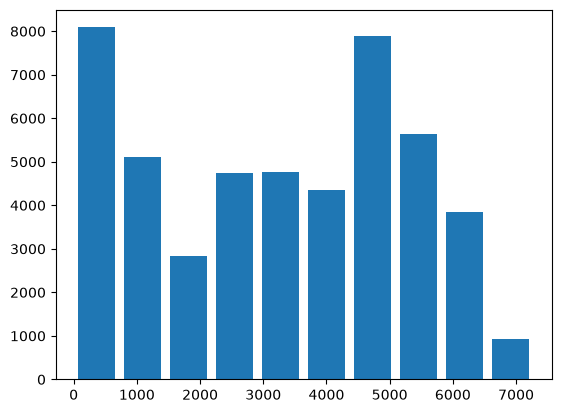

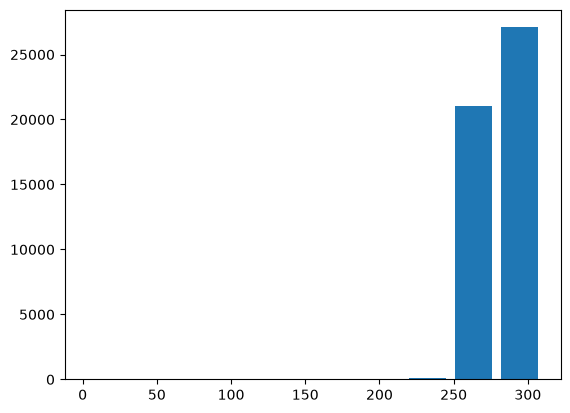

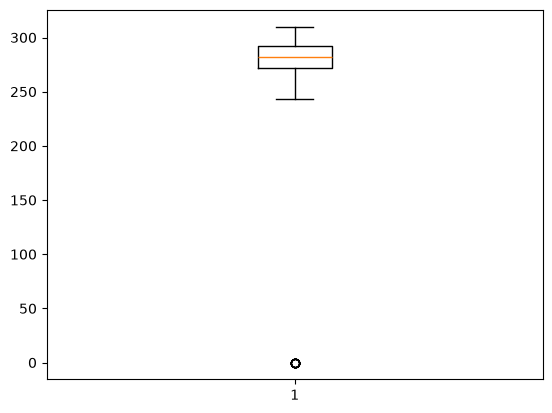

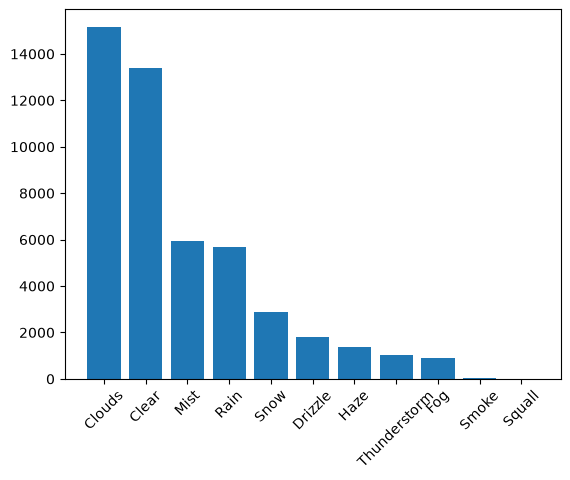

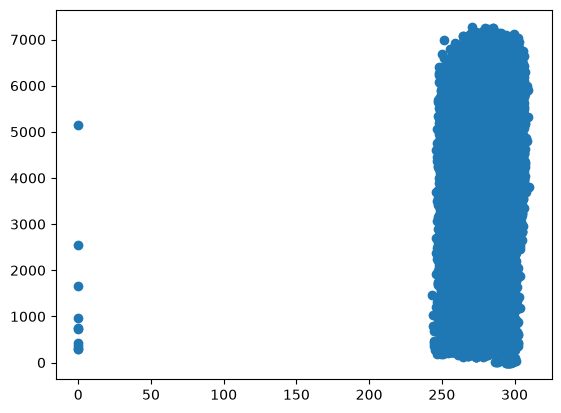

In [5]:
import matplotlib.pyplot as plt                   # Impor pustaka untuk grafik

plt.hist(df["traffic_volume"], rwidth=0.8)        # Grafik histrogram dari traffic volume
plt.show()

plt.hist(df["temp"], rwidth=0.8)                  # Grafik histrogram dari temp (sebaran frekuensi suhu)
plt.show()

plt.boxplot(df["temp"])                           # Grafik boxplot untuk kolom temp
plt.show()

hitung_cuaca = df["weather_main"].value_counts()  # Menghitung jumlah kemunculan dari tiap jenis cuaca
plt.bar(hitung_cuaca.index, hitung_cuaca.values)  # Membuat diagram batang, hitung_cuaca.index X, hitung_cuaca.values Y

plt.xticks(rotation=45)                           # Miringkan teks sumbu X agar tidak menimpa
plt.show()

plt.scatter(df["temp"], df["traffic_volume"])     # Membuat grafik sebar, Sumbu X: Suhu (df["temp"]), Sumbu Y: Volume kendaraan (df["traffic_volume"]) 
plt.show()

## Kesimpulan

**Jawaban dari Pertanyaan Analitis:**
1. **Bagaimana distribusi suhu rata-rata?** Rata-rata suhu di area jalan tol tersebut adalah 281,2 Kelvin (sekitar 8°C) dengan median 282,45 Kelvin. Sebarannya relatif simetris di rentang 260K hingga 300K, namun terdapat nilai ekstrem (0 Kelvin) yang merupakan kesalahan pencatatan.
2. **Jenis cuaca apa yang paling sering terjadi?** Cuaca berawan (Clouds) mendominasi dengan frekuensi 31,46% waktu pengamatan, disusul oleh cuaca cerah (Clear) sebesar 27,78%.
3. **Apakah suhu ekstrem memengaruhi volume kendaraan?** Berdasarkan *scatter plot*, tidak terlihat korelasi linear yang kuat antara suhu dan volume kendaraan. Volume lalu lintas tetap berfluktuasi tinggi pada rentang suhu normal.

**Temuan Menarik:**
1. Jalan tol ini sangat sibuk dengan rata-rata 3.259 kendaraan melintas setiap jamnya.
2. Cuaca ekstrem seperti badai salju (Squall) atau asap tebal (Smoke) sangat langka, menyumbang kurang dari 0,1% total waktu.
3. Ditemukan kecacatan pada data suhu berupa nilai 0 Kelvin mutlak, yang secara hukum fisika tidak mungkin terjadi di lingkungan Bumi, sehingga ini pasti diakibatkan oleh kerusakan sensor termometer di stasiun pengukur.

**Keterbatasan Data:**
Kolom `holiday` memiliki terlalu banyak data kosong (48.143 baris) karena format pencatatannya hanya diisi saat hari libur nasional saja. Selain itu, ada anomali sensor suhu (0 Kelvin) yang harus dibersihkan jika ingin melakukan analisis lebih lanjut.

**Ide Pertanyaan Lanjutan:**
1. Pada jam berapa (pagi, siang, atau malam) volume kendaraan mencapai titik puncak (Rush Hour)?
2. Apakah ada perbedaan signifikan volume lalu lintas antara hari kerja (Senin-Jumat) dibandingkan akhir pekan (Sabtu-Minggu)?

## Referensi dan Catatan Penggunaan AI

**Sumber Dataset:**
Dataset "Metro Interstate Traffic Volume" diperoleh dari UCI Machine Learning Repository. (Tautan: https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

**Tabel Catatan Penggunaan AI:**

| Alat | Dipakai untuk | Yang kami pelajari |
|---|---|---|
| AI (Gemini) | Memahami fungsi kode dasar Pandas (`read_csv`, `shape`, `head`, `info`, `isna`, `duplicated`) dan membandingkannya dengan bahasa C/C++ | Pandas memuat data CSV ke DataFrame secara instan tanpa perlu perulangan manual (`fopen`/`fscanf`) seperti di C/C++. |
| AI (Gemini) | Memahami Kamus Data dan penulisan sintaks tabel Markdown | Kolom `holiday` bernilai `NaN` pada hari biasa, dan simbol garis tegak (`\|`) pada Markdown digunakan untuk membentuk visual tabel HTML. |
| AI (Gemini) | Menginterpretasikan hasil statistik deskriptif (`describe`, `mode`, `var`) | Menemukan anomali sensor pada suhu 0 Kelvin (-273,15°C) serta memahami varians tinggi yang menandakan dinamika volume kendaraan. |
| AI (Gemini) | Memahami analisis variabel kategorik cuaca (`value_counts`) | Menggunakan `normalize=True` untuk menghitung persentase dan `.idxmax()` untuk menentukan modus cuaca utama (`Clouds`). |
| AI (Gemini) | Menyederhanakan kode visualisasi Matplotlib (`hist`, `boxplot`, `bar`, `scatter`) dari level lanjut ke level pemula | Menggunakan fungsi plotting dasar Matplotlib tanpa kustomisasi rumit agar kode terlihat lebih natural untuk tingkat dasar. |
| AI (Gemini) | *Debugging* masalah grafik yang bertumpuk dan teks sumbu X yang berantakan | Pentingnya memanggil `plt.show()` untuk memisahkan kanvas tiap grafik dan `plt.xticks(rotation=45)` agar teks sumbu X tidak bertumpuk. |